In [ ]:
import random
import math
import windfarm_eval
import matplotlib.pyplot as plt

# -----------------------------
# Fonction pour ajouter 1 turbine
# -----------------------------
def add_turbine(turbines, x_min, x_max, y_min, y_max, min_dist, max_attempts=5000):
    attempts = 0
    while attempts < max_attempts:
        x = random.uniform(x_min, x_max)
        y = random.uniform(y_min, y_max)

        too_close = any(math.hypot(tx - x, ty - y) < min_dist for tx, ty in turbines)

        if not too_close:
            return turbines + [(x, y)]  # nouvelle liste avec la turbine en plus

        attempts += 1

    return None  # échec

# -----------------------------
# Paramètres
# -----------------------------
n_max = 20
x_min, x_max = 104500, 107500
y_min, y_max = 1043500, 1045600
diameter = 80
min_dist = 2 * diameter

x0_file = 'instances/1/x0_generated.txt'
param_file = 'instances/1/param.txt'

# -----------------------------
# Process incrémental avec validation
# -----------------------------
turbines = []
n = 1

while n <= n_max:
    new_turbines = add_turbine(turbines, x_min, x_max, y_min, y_max, min_dist)

    if new_turbines is None:
        print(f"⚠️ Impossible de placer une {n}ᵉ turbine après trop d’essais. On arrête.")
        break

    coords = [coord for turbine in new_turbines for coord in turbine]

    with open(x0_file, 'w') as f:
        f.write(str(coords))

    eap, spacing_constraint, placing_constraint = windfarm_eval.windfarm_eval(param_file, x0_file)

    if spacing_constraint == 0 and placing_constraint == 0:
        turbines = new_turbines
        print(f"✅ Turbine {n} placée. EAP = {eap}")
        n += 1
    else:
        print(f"❌ Turbine {n} non valide → spacing_constraint = {spacing_constraint}, placing_constraint = {placing_constraint}")

# -----------------------------
# Plot final
# -----------------------------
if turbines:
    x_coords, y_coords = zip(*turbines)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f"Disposition finale de {len(turbines)} éoliennes")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    # Scatter des centres
    ax.scatter(x_coords, y_coords, color="blue", label="Éoliennes")

    # Cercle de rotor (diamètre)
    for (x, y) in turbines:
        circle = plt.Circle((x, y), diameter / 2, color="blue", fill=False, linestyle="--")
        ax.add_patch(circle)

    # Limites du terrain
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.show()


In [3]:
import random
import math
import windfarm_eval
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Paramètres
# -----------------------------
n_turbines = 10
x_min, x_max = 104500, 107500
y_min, y_max = 1043500, 1045600
diameter = 80
min_dist = 2 * diameter

param_file = "instances/1/param.txt"
x0_file = "instances/1/x0_gradient.txt"

# -----------------------------
# Génération initiale aléatoire valide
# -----------------------------
def add_turbine(turbines):
    max_attempts = 5000
    attempts = 0
    while attempts < max_attempts:
        x = random.uniform(x_min, x_max)
        y = random.uniform(y_min, y_max)
        too_close = any(math.hypot(tx - x, ty - y) < min_dist for tx, ty in turbines)
        if not too_close:
            return turbines + [(x, y)]
        attempts += 1
    return None

def generate_initial_coords(n_turbines):
    turbines = []
    while len(turbines) < n_turbines:
        new_turbines = add_turbine(turbines)
        if new_turbines is None:
            turbines = []
            continue
        coords = [c for t in new_turbines for c in t]
        with open(x0_file, "w") as f:
            f.write(str(coords))
        eap, spacing, placing = windfarm_eval.windfarm_eval(param_file, x0_file)
        if spacing == 0 and placing == 0:
            turbines = new_turbines
    return np.array([c for t in turbines for c in t], dtype=float)

coords = generate_initial_coords(n_turbines)

# -----------------------------
# Fonction objectif
# -----------------------------
def objective(x):
    coords_list = x.tolist()
    with open(x0_file, "w") as f:
        f.write(str(coords_list))
    eap, spacing, placing = windfarm_eval.windfarm_eval(param_file, x0_file)
    if spacing != 0 or placing != 0:
        return -1e6
    return -eap  # on minimise -EAP pour maximiser EAP

# -----------------------------
# Estimation du gradient par différences finies
# -----------------------------
def finite_diff_grad(f, x, epsilon=1e-2):
    grad = np.zeros_like(x)
    fx = f(x)
    for i in range(len(x)):
        x_eps = x.copy()
        x_eps[i] += epsilon
        grad[i] = (f(x_eps) - fx) / epsilon
    return grad

# -----------------------------
# Gradient ascent (descente de -EAP)
# -----------------------------
learning_rate = 100.0
max_iter = 50

for it in range(max_iter):
    grad = finite_diff_grad(objective, coords)
    coords -= learning_rate * grad  # descente de -EAP = ascente de EAP

    # clip pour rester dans les limites
    for i in range(len(coords)):
        if i % 2 == 0:
            coords[i] = np.clip(coords[i], x_min, x_max)
        else:
            coords[i] = np.clip(coords[i], y_min, y_max)

    eap_val = -objective(coords)
    print(f"Iter {it+1}: EAP = {eap_val:.2f}")

# -----------------------------
# Plot final
# -----------------------------
best_coords = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
x_coords, y_coords = zip(*best_coords)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(x_coords, y_coords, color="blue")
for (x,y) in best_coords:
    circle = plt.Circle((x,y), diameter/2, fill=False, linestyle="--")
    ax.add_patch(circle)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect("equal")
ax.set_title("Optimisation par gradient (différence finie)")
plt.show()


Iter 1: EAP = 20.03
Iter 2: EAP = 20.03


KeyboardInterrupt: 

In [9]:
import random
import math
import windfarm_eval
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Paramètres
# -----------------------------
n_turbines = 10
x_min, x_max = 104500, 107500
y_min, y_max = 1043500, 1045600
diameter = 80
min_dist = 2 * diameter
eps = 10             # pas pour gradient
alpha = 1         # learning rate
max_iter = 50       # nombre max d'itérations

param_file = "instances/1/param.txt"
x0_file = "instances/1/x0_gradient.txt"
x0p_file = "instances/1/x0p_generated.txt"
x0m_file = "instances/1/x0m_generated.txt"

# -----------------------------
# Fonction pour générer une turbine valide
# -----------------------------
def add_turbine(turbines):
    max_attempts = 5000
    for _ in range(max_attempts):
        x = random.uniform(x_min, x_max)
        y = random.uniform(y_min, y_max)
        if all(math.hypot(tx - x, ty - y) >= min_dist for tx, ty in turbines):
            return turbines + [(x, y)]
    return None

# -----------------------------
# Génération d'une configuration initiale
# -----------------------------
def generate_initial_turbines():
    turbines = []
    for n in range(n_turbines):
        turbines = add_turbine(turbines)
        if turbines is None:
            return None
    return turbines

# -----------------------------
# Gradient par différences finies
# -----------------------------
def compute_gradient(turbines, eps=eps):
    grad = np.zeros(2 * n_turbines)
    for i in range(n_turbines):
        for j in range(2):
            turb_plus = turbines.copy()
            turb_minus = turbines.copy()

            if j == 0:  # x
                turb_plus[i] = (turb_plus[i][0] + eps, turb_plus[i][1])
                turb_minus[i] = (turb_minus[i][0] - eps, turb_minus[i][1])
            else:       # y
                turb_plus[i] = (turb_plus[i][0], turb_plus[i][1] + eps)
                turb_minus[i] = (turb_minus[i][0], turb_minus[i][1] - eps)

            coords_plus = [c for t in turb_plus for c in t]
            coords_minus = [c for t in turb_minus for c in t]

            # Écrire fichiers temporaires pour windfarm_eval
            with open(x0p_file, "w") as f:
                f.write(str(coords_plus))
            with open(x0m_file, "w") as f:
                f.write(str(coords_minus))

            eap_plus, spacing_p, placing_p = windfarm_eval.windfarm_eval(param_file, x0p_file)
            eap_minus, spacing_m, placing_m = windfarm_eval.windfarm_eval(param_file, x0m_file)

            # Pénaliser les positions invalides
            #if spacing_p != 0 or placing_p != 0:
            #    eap_plus += - 10e6
            #if spacing_m != 0 or placing_m != 0:
            #    eap_minus += - 10e6

            grad[2*i + j] = (eap_plus - eap_minus) / (2*eps)
    return grad

# -----------------------------
# Gradient ascent
# -----------------------------
turbines = None
while turbines is None:
    turbines = generate_initial_turbines()

turbines = np.array(turbines, dtype=float)

for iteration in range(max_iter):
    grad = compute_gradient(turbines.tolist())
    turbines += alpha * grad.reshape(-1,2)

    # Clip pour rester dans le terrain
    turbines[:,0] = np.clip(turbines[:,0], x_min, x_max)
    turbines[:,1] = np.clip(turbines[:,1], y_min, y_max)

    # Vérification distance minimale
    valid = True
    for i in range(n_turbines):
        for j in range(i+1, n_turbines):
            if math.hypot(turbines[i,0]-turbines[j,0], turbines[i,1]-turbines[j,1]) < min_dist:
                valid = False
                break
        if not valid:
            break
    if not valid:
        print(f"⚠️ Contrainte min_dist violée à l'itération {iteration}, on réduit alpha")
        alpha *= 0.5
        continue

    # Évaluation finale
    coords = [c for t in turbines for c in t]
    with open(x0_file, "w") as f:
        f.write(str(coords))
    eap, spacing, placing = windfarm_eval.windfarm_eval(param_file, x0_file)
    print(f"Iteration {iteration+1}: EAP = {eap}, spacing={spacing}, placing={placing}")

# -----------------------------
# Plot final
# -----------------------------
x_coords, y_coords = turbines[:,0], turbines[:,1]
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(x_coords, y_coords, color="blue")
for (x, y) in zip(x_coords, y_coords):
    circle = plt.Circle((x, y), diameter/2, fill=False, linestyle="--")
    ax.add_patch(circle)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect("equal")
ax.set_title("Disposition optimisée des turbines")
plt.show()


Iteration 1: EAP = 20.342631829826654, spacing=0, placing=1740.2013724381152
Iteration 2: EAP = 20.342639740502996, spacing=0, placing=1740.2026155325123
Iteration 3: EAP = 20.342647650923997, spacing=0, placing=1740.2038585942848
Iteration 4: EAP = 20.34265556108978, spacing=0, placing=1740.205101623411
Iteration 5: EAP = 20.34266347100069, spacing=0, placing=1740.2063446200755
Iteration 6: EAP = 20.342671380655933, spacing=0, placing=1740.207587584087
Iteration 7: EAP = 20.342679290056488, spacing=0, placing=1740.2088305155357
Iteration 8: EAP = 20.34268719920116, spacing=0, placing=1740.21007341434
Iteration 9: EAP = 20.342695108090492, spacing=0, placing=1740.2113162806363
Iteration 10: EAP = 20.34270301672435, spacing=0, placing=1740.2125591142958
Iteration 11: EAP = 20.342710932909824, spacing=0, placing=1740.213801915409


KeyboardInterrupt: 

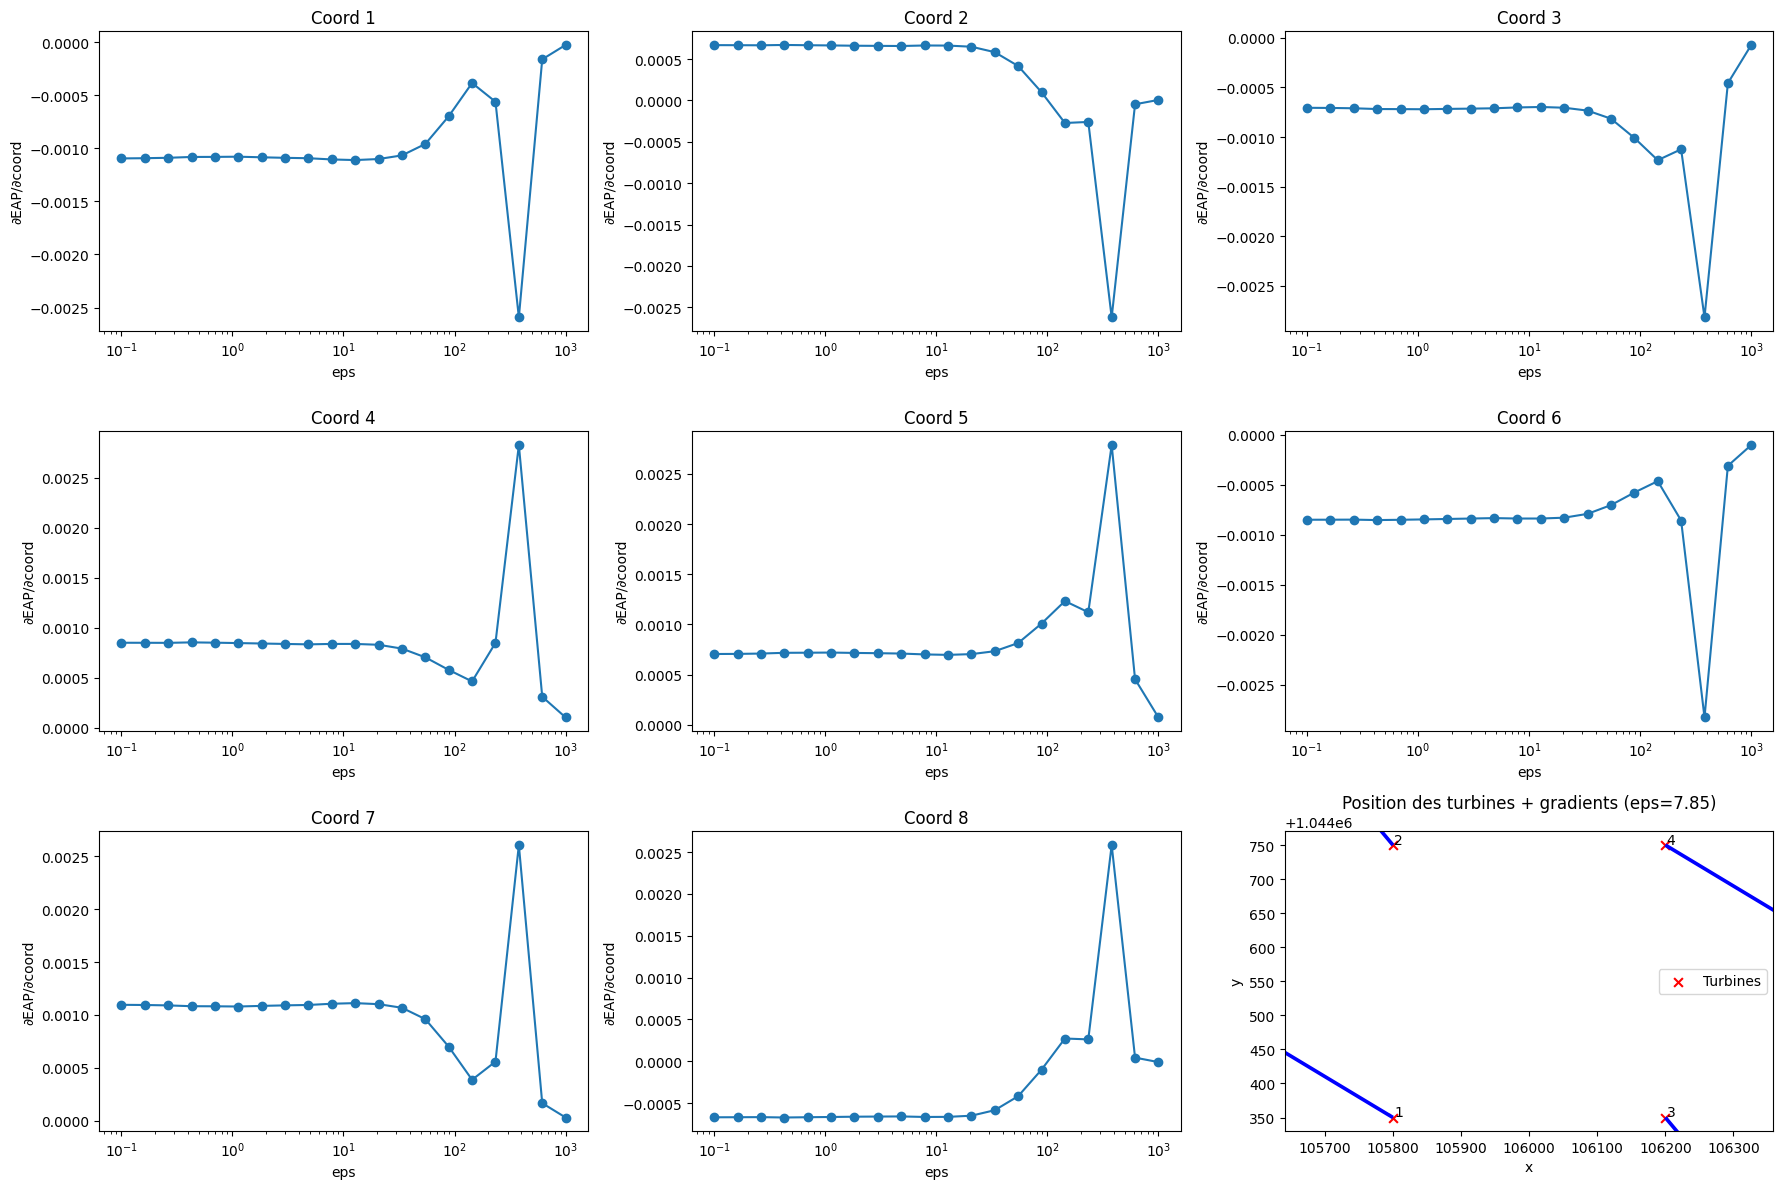

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import windfarm_eval
import windValid

# -----------------------------
# Paramètres
# -----------------------------
n_max = 4
eps_values = np.logspace(-1, 3, 20)  # eps = 0.1 → 1000
param_file = "instances/1/param.txt"
x0p_file = "instances/1/x0p_generated.txt"
x0m_file = "instances/1/x0m_generated.txt"
x_min, x_max = 104500, 107500
y_min, y_max = 1043500, 1045600

# -----------------------------
# Fonction gradient coordonnée
# -----------------------------
def finite_diff_grad(turbSimu, eps):
    grad = np.zeros(2*n_max)
    for i in range(n_max):
        for j in range(2):  # x ou y
            turbxPlus = turbSimu.copy()
            turbxMoins = turbSimu.copy()

            turbxPlus[i] = (turbxPlus[i][0] + (1-j)*eps,
                            turbxPlus[i][1] + j*eps)
            turbxMoins[i] = (turbxMoins[i][0] - (1-j)*eps,
                             turbxMoins[i][1] - j*eps)

            coordsPlus = [c for t in turbxPlus for c in t]
            coordsMoins = [c for t in turbxMoins for c in t]

            with open(x0p_file, "w") as fp:
                fp.write(str(coordsPlus))
            with open(x0m_file, "w") as fm:
                fm.write(str(coordsMoins))

            f_plus, _, _ = windfarm_eval.windfarm_eval(param_file, x0p_file)
            f_moins, _, _ = windfarm_eval.windfarm_eval(param_file, x0m_file)

            grad[2*i+j] = (f_plus - f_moins) / (2*eps)
    return grad

def init_square_turbines(x_min, x_max, y_min, y_max, spacing=200):
    """
    Initialise 4 turbines en carré au centre du domaine.
    spacing = demi-côté du carré
    """
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2

    turbines = [
        (x_center - spacing, y_center - spacing),
        (x_center - spacing, y_center + spacing),
        (x_center + spacing, y_center - spacing),
        (x_center + spacing, y_center + spacing),
    ]
    return turbines

# -----------------------------
# Calcul pour différents eps
# -----------------------------
#turbines = windValid.valid(n_max)
turbines = init_square_turbines(x_min,x_max,y_min,y_max)
grad_eps = np.zeros((len(eps_values), 2*n_max))

for k, eps in enumerate(eps_values):
    grad_eps[k, :] = finite_diff_grad(turbines, eps)

# On choisit un eps représentatif (par exemple eps=10 → indice)
eps_index = np.argmin(np.abs(eps_values - 10))
grad_selected = grad_eps[eps_index, :]

# -----------------------------
# Plot des 8 gradients + turbines
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # 3x3 = 9 cases
axes = axes.flatten()

# 8 premiers plots : gradients
for idx in range(2*n_max):
    axes[idx].plot(eps_values, grad_eps[:, idx], marker='o')
    axes[idx].set_xscale("log")
    axes[idx].set_title(f"Coord {idx+1}")
    axes[idx].set_xlabel("eps")
    axes[idx].set_ylabel("∂EAP/∂coord")

# 9ème plot : turbines avec numéros + flèches gradient
ax_turb = axes[-1]
x, y = zip(*turbines)
ax_turb.scatter(x, y, c="red", marker="x", s=40, label="Turbines")

# Flèches de gradient
for i in range(n_max):
    gx, gy = grad_selected[2*i], grad_selected[2*i+1]
    ax_turb.quiver(x[i], y[i], gx, gy, angles="xy", scale_units="xy", scale=0.000002, color="blue")
    ax_turb.text(x[i] + 2, y[i] + 2, str(i+1), fontsize=10, color="black")

ax_turb.set_xlim(x_min, x_max)
ax_turb.set_ylim(y_min, y_max)
ax_turb.set_title(f"Position des turbines + gradients (eps={eps_values[eps_index]:.2f})")
ax_turb.set_xlabel("x")
ax_turb.set_ylabel("y")
ax_turb.legend()
ax_turb.axis("equal")

plt.tight_layout()
plt.show()
